In [2]:
import pandas as pd
import matplotlib.pyplot as plt

EXCEL_FILE = "normals.xlsx"         
SHEETS = {"Idabel": "Idabel", "Boise_City": "Boise City"}
COLORS = {"Idabel": "#FF6600", "Boise City": "#1F4E79"}
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

def monthly(sheet):
    d = pd.read_excel(EXCEL_FILE, sheet_name=sheet)
    d.columns = [c.strip().lower() for c in d.columns]
    pcpn_col = [c for c in d.columns if "pcpn" in c][0]    
    d["pcpn_daily"] = d[pcpn_col].diff()
    d.loc[d.index[0], "pcpn_daily"] = d[pcpn_col].iloc[0]
    d.loc[d["pcpn_daily"] < 0, "pcpn_daily"] = 0
    d["month"] = pd.PeriodIndex(
        pd.date_range("2021-01-01", periods=len(d), freq="D"), freq="M").month
    return pd.DataFrame({
        "month": range(1, 13),
        "MeanT":  d.groupby("month")["avgt"].mean().values,
        "Precip": d.groupby("month")["pcpn_daily"].sum().values,
    })

data = {label: monthly(sheet) for sheet, label in SHEETS.items()}



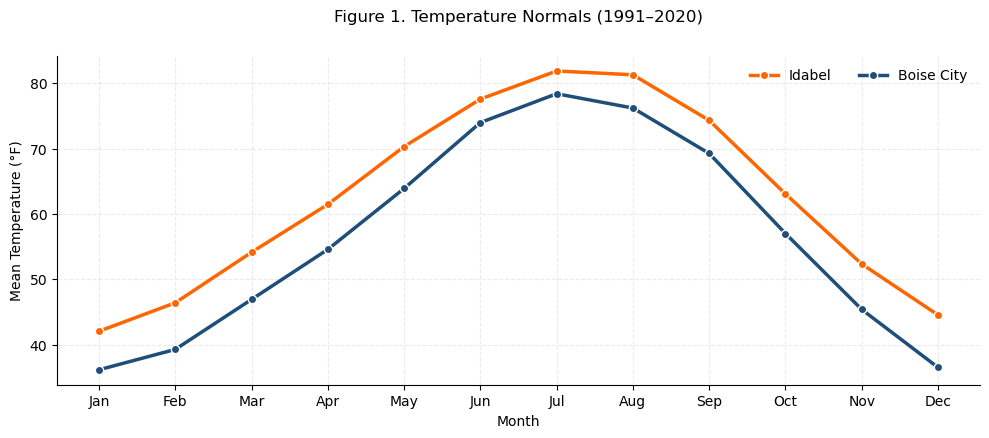

In [54]:
# Figure 1 — Temperature normals
fig, ax = plt.subplots(figsize=(10, 4.5))
for label, m in data.items():
    ax.plot(m["month"], m["MeanT"], marker="o", linewidth=2.5,
            color=COLORS[label], markeredgecolor="white", label=label)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
ax.set_xlabel("Month"); ax.set_ylabel("Mean Temperature (°F)")
ax.set_title("Figure 1. Temperature Normals (1991–2020)", y=1.08)
ax.grid(axis="both", alpha=0.25,linestyle='--'); ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig("Figure1_Temperature_Normals.png", dpi=300, bbox_inches="tight")
plt.show()



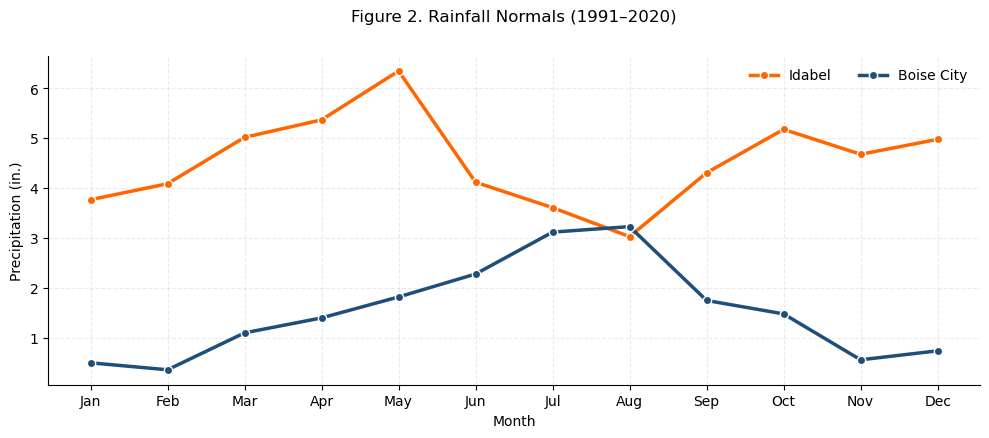

In [53]:
# Figure 2 — Rainfall normals
fig, ax = plt.subplots(figsize=(10, 4.5))
for label, m in data.items():
    ax.plot(m["month"], m["Precip"], marker="o", linewidth=2.5,
            color=COLORS[label], markeredgecolor="white", label=label)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
ax.set_xlabel("Month"); ax.set_ylabel("Precipitation (in.)")
ax.set_title("Figure 2. Rainfall Normals (1991–2020)",y=1.08)
ax.grid(axis="both", alpha=0.25,linestyle='--'); ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig("Figure2_Rainfall_Normals.png", dpi=300, bbox_inches="tight")
plt.show()

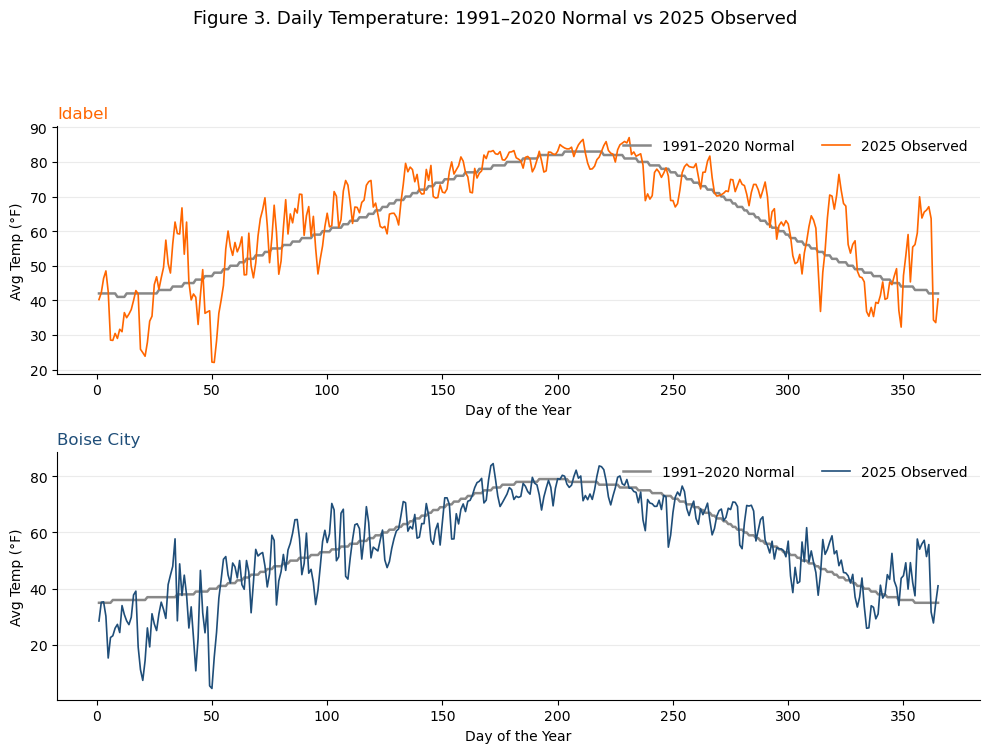

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
NORMALS_FILE  = "normals.xlsx"
OBS_2025_FILE = "Data_2025.csv"
SHEETS = {"Idabel": "Idabel", "Boise_City": "Boise City"}
STID   = {"IDAB": "Idabel", "BOIS": "Boise City"}
COLORS = {"Idabel": "#FF6600", "Boise City": "#1F4E79"}
MISSING = [-994, -995, -996, -997, -998, -999, -9999]

# ---------- 1991-2020 DAILY avgt NORMAL ----------
def daily_temp_normal(sheet):
    d = pd.read_excel(NORMALS_FILE, sheet_name=sheet)
    d.columns = [c.strip().lower() for c in d.columns]
    return d["avgt"].reset_index(drop=True)

normal_t = {label: daily_temp_normal(sheet) for sheet, label in SHEETS.items()}

# ---------- 2025 OBSERVED DAILY TAVG ----------
df = pd.read_csv(OBS_2025_FILE)
df.columns = [c.strip().upper() for c in df.columns]
df["TAVG"] = df["TAVG"].replace(MISSING, pd.NA)
df["site"] = df["STID"].map(STID)
df["date"] = pd.to_datetime(df[["YEAR","MONTH","DAY"]])
df["doy"]  = df["date"].dt.dayofyear

# ================= FIGURE 3 =================
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

for ax, site in zip(axes, ["Idabel", "Boise City"]):
    obs = df[df["site"] == site].sort_values("doy")
    norm = normal_t[site]
    ax.plot(range(1, len(norm)+1), norm.values, color="#888888",
            linewidth=1.8, label="1991–2020 Normal")
    ax.plot(obs["doy"], obs["TAVG"], color=COLORS[site],
            linewidth=1.2, label="2025 Observed")
    ax.set_title(site, loc="left", color=COLORS[site], fontsize=12)
    ax.set_ylabel("Avg Temp (°F)")
    ax.set_xlabel("Day of the Year")
    ax.set_xticks(range(0, 366, 50))         
    ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="upper right", ncol=2)

fig.suptitle("Figure 3. Daily Temperature: 1991–2020 Normal vs 2025 Observed",
             fontsize=13, y=1.07)
fig.tight_layout()
fig.savefig("Figure3_Daily_Temp_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

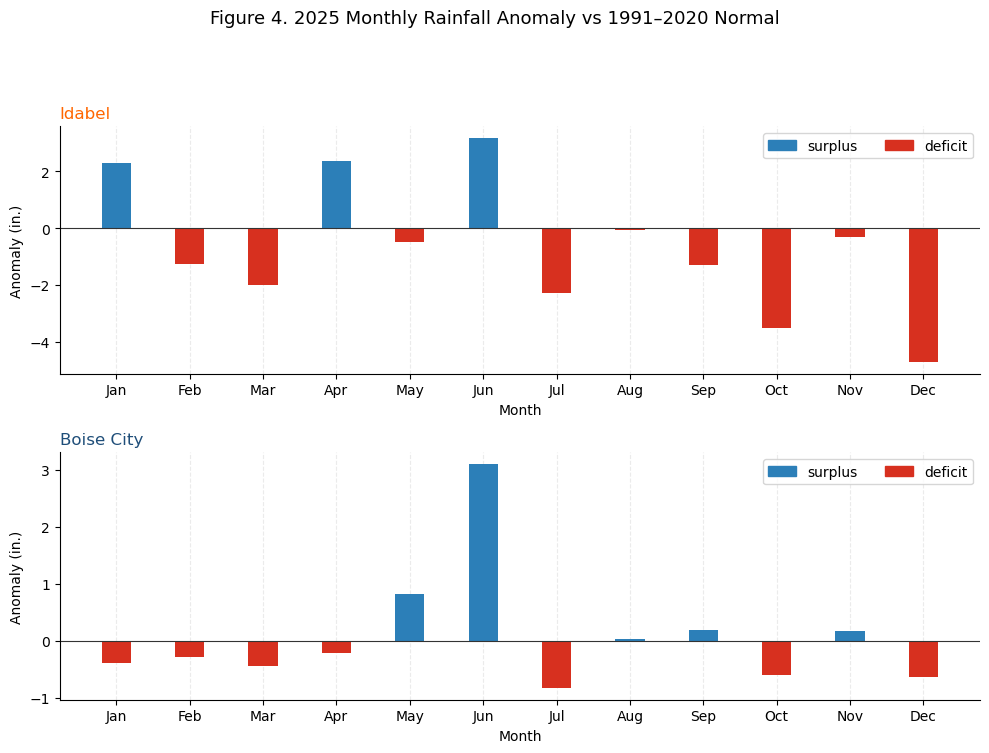

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------- CONFIG ----------
NORMALS_FILE  = "normals.xlsx"
OBS_2025_FILE = "Data_2025.csv"
SHEETS = {"Idabel": "Idabel", "Boise_City": "Boise City"}
STID   = {"IDAB": "Idabel", "BOIS": "Boise City"}
COLORS = {"Idabel": "#FF6600", "Boise City": "#1F4E79"}
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
MISSING = [-994, -995, -996, -997, -998, -999, -9999]

# ---------- 1991-2020 MONTHLY PRECIP NORMAL ----------
def monthly_precip_normal(sheet):
    d = pd.read_excel(NORMALS_FILE, sheet_name=sheet)
    d.columns = [c.strip().lower() for c in d.columns]
    pcol = [c for c in d.columns if "pcpn" in c][0]
    daily = d[pcol].diff()
    daily.iloc[0] = d[pcol].iloc[0]
    daily[daily < 0] = 0
    month = pd.PeriodIndex(
        pd.date_range("2021-01-01", periods=len(d), freq="D"), freq="M").month
    return daily.groupby(month).sum().reindex(range(1,13)).values

normal_rain = {label: monthly_precip_normal(sheet) for sheet, label in SHEETS.items()}

# ---------- 2025 OBSERVED MONTHLY RAIN ----------
df = pd.read_csv(OBS_2025_FILE)
df.columns = [c.strip().upper() for c in df.columns]
df["RAIN"] = df["RAIN"].replace(MISSING, pd.NA)
df["site"] = df["STID"].map(STID)
obs_rain = (df.groupby(["site","MONTH"])["RAIN"].sum()
              .unstack("site").reindex(range(1,13)))

# ================= FIGURE 4 =================
legend_handles = [
    Patch(color="#2c7fb8", label="surplus"),
    Patch(color="#d7301f", label="deficit"),
]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)
for ax, site in zip(axes, ["Idabel", "Boise City"]):
    anom = obs_rain[site].values - normal_rain[site]
    bar_colors = ["#2c7fb8" if a >= 0 else "#d7301f" for a in anom]  
    ax.bar(range(1,13), anom, color=bar_colors, width=0.4)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set_title(site, loc="left", color=COLORS[site], fontsize=12)
    ax.set_ylabel("Anomaly (in.)")
    ax.set_xlabel("Month")
    ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS)
    ax.grid(axis="x", alpha=0.25,linestyle='--'); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(handles=legend_handles, frameon=True, loc="upper right", ncol=2)

fig.suptitle("Figure 4. 2025 Monthly Rainfall Anomaly vs 1991–2020 Normal",
             fontsize=13, y=1.07)
fig.tight_layout()
fig.savefig("Figure4_Rainfall_Anomaly_2025.png", dpi=300, bbox_inches="tight")
plt.show()

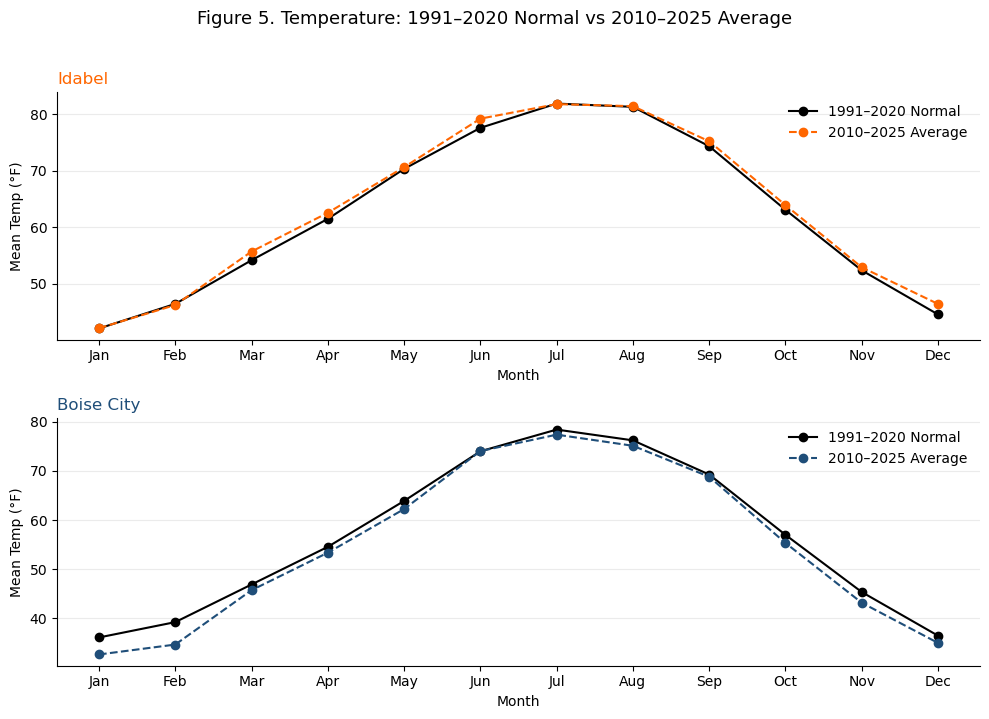

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
NORMALS_FILE = "normals.xlsx"
OBS_FILE     = "Data_2010_2025.csv"
SHEETS = {"Idabel": "Idabel", "Boise_City": "Boise City"}
STID   = {"IDAB": "Idabel", "BOIS": "Boise City"}
COLORS = {"Idabel": "#FF6600", "Boise City": "#1F4E79"}
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
MISSING = [-994, -995, -996, -997, -998, -999, -9999]

# ---------- 1991-2020 MONTHLY MEAN TEMP NORMAL ----------
def monthly_temp_normal(sheet):
    d = pd.read_excel(NORMALS_FILE, sheet_name=sheet)
    d.columns = [c.strip().lower() for c in d.columns]
    month = pd.PeriodIndex(
        pd.date_range("2021-01-01", periods=len(d), freq="D"), freq="M").month
    return d.groupby(month)["avgt"].mean().reindex(range(1,13)).values

normal_t = {label: monthly_temp_normal(sheet) for sheet, label in SHEETS.items()}

# ---------- 2010-2025 RECENT MONTHLY MEAN TEMP ----------
df = pd.read_csv(OBS_FILE)
df.columns = [c.strip().upper() for c in df.columns]
df["TAVG"] = df["TAVG"].replace(MISSING, pd.NA)
df["site"] = df["STID"].map(STID)
# average each calendar month across all years 2010-2025
recent_t = (df.groupby(["site","MONTH"])["TAVG"].mean()
              .unstack("site").reindex(range(1,13)))

# ================= FIGURE 5 =================
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)
for ax, site in zip(axes, ["Idabel", "Boise City"]):
    ax.plot(range(1,13), normal_t[site], marker="o", linewidth=1.5,
            color='black', label="1991–2020 Normal")
    ax.plot(range(1,13), recent_t[site].values, marker="o", linewidth=1.5,
            linestyle="--", color=COLORS[site], label="2010–2025 Average")
    ax.set_title(site, loc="left", color=COLORS[site], fontsize=12)
    ax.set_ylabel("Mean Temp (°F)")
    ax.set_xlabel("Month")
    ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS)
    ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="best", ncol=1)

fig.suptitle("Figure 5. Temperature: 1991–2020 Normal vs 2010–2025 Average",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("Figure5_Temp_15yr_vs_30yr.png", dpi=300, bbox_inches="tight")
plt.show()

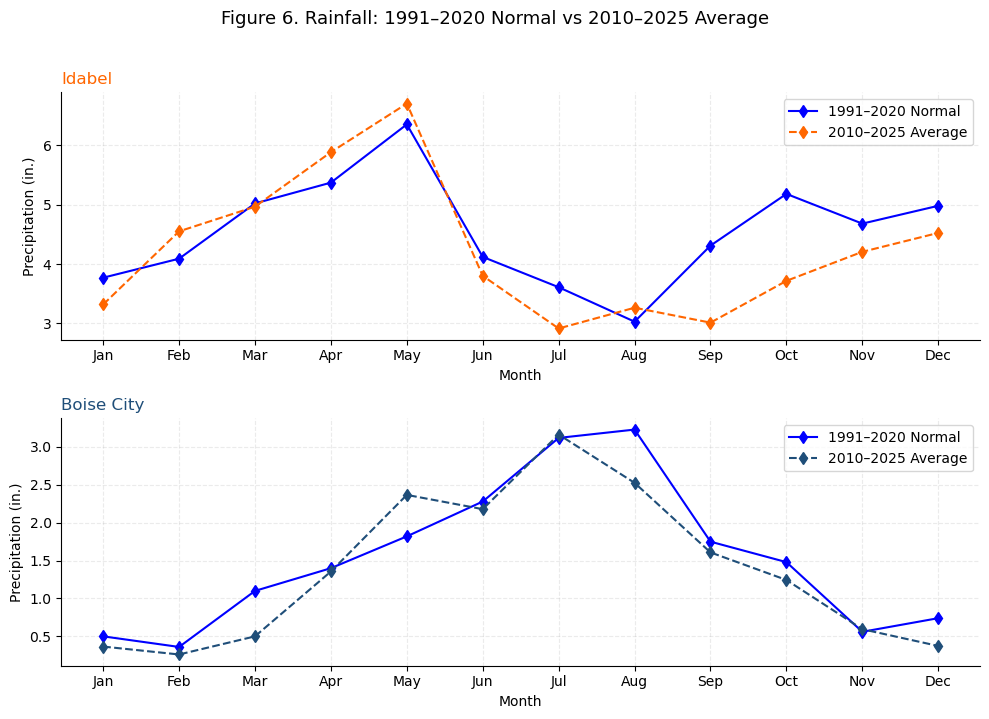

In [55]:
# ---------- 1991-2020 MONTHLY PRECIP NORMAL  ----------
def monthly_precip_normal(sheet):
    d = pd.read_excel(NORMALS_FILE, sheet_name=sheet)
    d.columns = [c.strip().lower() for c in d.columns]
    pcol = [c for c in d.columns if "pcpn" in c][0]
    daily = d[pcol].diff(); daily.iloc[0] = d[pcol].iloc[0]; daily[daily < 0] = 0
    month = pd.PeriodIndex(
        pd.date_range("2021-01-01", periods=len(d), freq="D"), freq="M").month
    return daily.groupby(month).sum().reindex(range(1,13)).values

normal_rain = {label: monthly_precip_normal(sheet) for sheet, label in SHEETS.items()}

# ---------- 2010-2025 RECENT MONTHLY RAIN ----------
df = pd.read_csv(OBS_FILE)
df.columns = [c.strip().upper() for c in df.columns]
df["RAIN"] = df["RAIN"].replace(MISSING, pd.NA)
df["site"] = df["STID"].map(STID)
# step 1: total rain per site-year-month ; step 2: average those totals across years
yearly = df.groupby(["site","YEAR","MONTH"])["RAIN"].sum().reset_index()
recent_rain = (yearly.groupby(["site","MONTH"])["RAIN"].mean()
                     .unstack("site").reindex(range(1,13)))

# ================= FIGURE 6 =================
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)
for ax, site in zip(axes, ["Idabel", "Boise City"]):
    ax.plot(range(1,13), normal_rain[site], marker="d", linewidth=1.5,
            color='blue', label="1991–2020 Normal")
    ax.plot(range(1,13), recent_rain[site].values, marker="d", linewidth=1.5,
            linestyle="--", color=COLORS[site], label="2010–2025 Average")
    ax.set_title(site, loc="left", color=COLORS[site], fontsize=12)
    ax.set_ylabel("Precipitation (in.)")
    ax.set_xlabel("Month")
    ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS)
    ax.grid(axis="both", alpha=0.25,linestyle='--'); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(frameon=True, loc="upper right", ncol=1)

fig.suptitle("Figure 6. Rainfall: 1991–2020 Normal vs 2010–2025 Average",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("Figure6_Rainfall_15yr_vs_30yr.png", dpi=300, bbox_inches="tight")
plt.show()